<a href="https://colab.research.google.com/github/Alhaziq16/Group-Project-Pai/blob/main/Data_Analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Analyst Phase

## Cat Breed Classification Using Deep Learning

Models Compared:
- ResNet50
- DenseNet121
- MobileNetV3

Dataset:
10 Cat Breeds from Kaggle

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [6]:
!ls /content

cat_split_dataset.zip  sample_data


In [7]:
!unzip -q /content/cat_split_dataset.zip

In [9]:
!ls /content/cat_split_dataset

test  train  val


In [10]:
breed_counts = {}

train_path = "/content/cat_split_dataset/train"

for breed in os.listdir(train_path):
    breed_path = os.path.join(train_path, breed)

    if os.path.isdir(breed_path):
        breed_counts[breed] = len(os.listdir(breed_path))

breed_counts

{'Birman': 158,
 'Abyssinian': 178,
 'British Shorthair': 396,
 'Siamese': 2021,
 'Ragdoll': 1868,
 'Maine Coon': 992,
 'Bombay': 1284,
 'American Shorthair': 3706,
 'Bengal': 1733,
 'American Bobtail': 693}

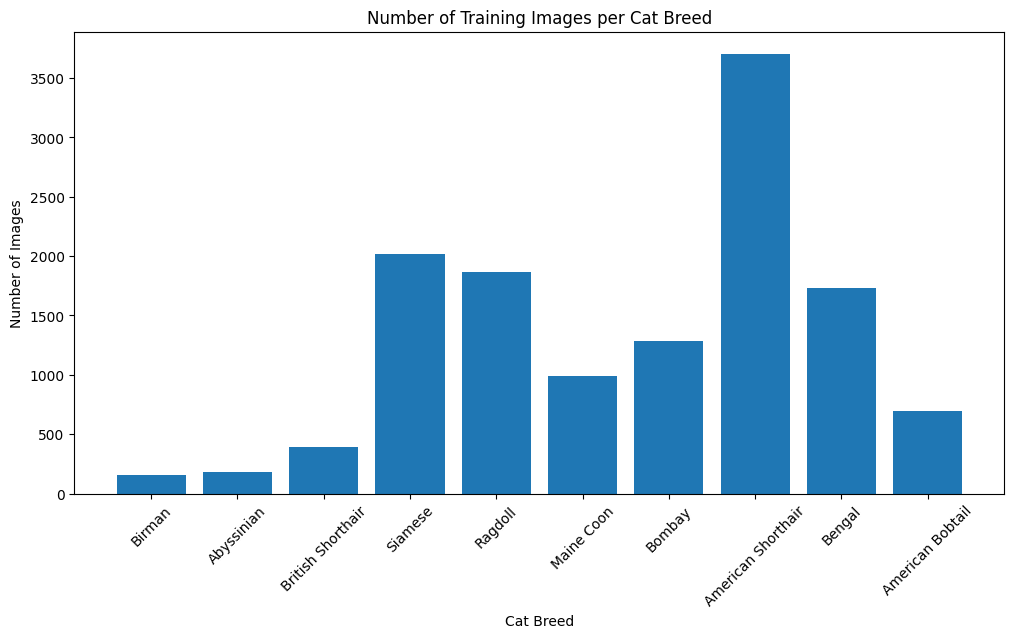

In [11]:
plt.figure(figsize=(12,6))

plt.bar(
    breed_counts.keys(),
    breed_counts.values()
)

plt.title("Number of Training Images per Cat Breed")
plt.xlabel("Cat Breed")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

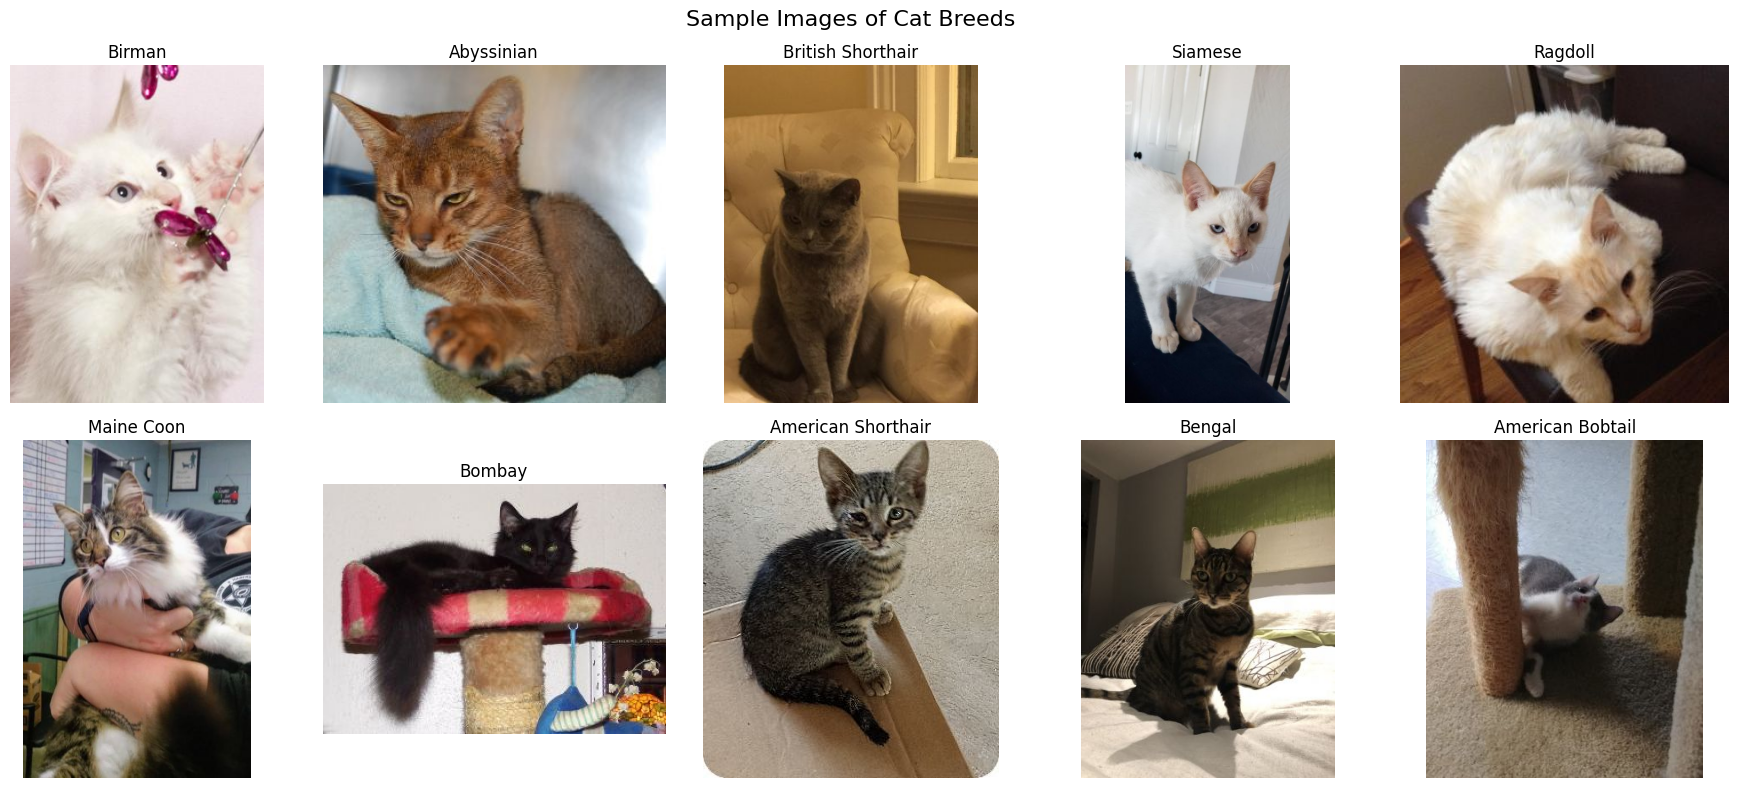

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

train_path = "/content/cat_split_dataset/train"

breeds = list(breed_counts.keys())

for ax, breed in zip(axes.flatten(), breeds):
    breed_folder = os.path.join(train_path, breed)

    image_name = os.listdir(breed_folder)[0]   # take the first image
    image_path = os.path.join(breed_folder, image_name)

    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(breed)
    ax.axis("off")

plt.suptitle("Sample Images of Cat Breeds", fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
import json

with open('/content/resnet_history.json', 'r') as f:
    resnet_history = json.load(f)

with open('/content/densenet_history.json', 'r') as f:
    densenet_history = json.load(f)

with open('/content/mobilenet_history.json', 'r') as f:
    mobilenet_history = json.load(f)

print("Histories loaded successfully!")

Histories loaded successfully!


In [16]:
print(resnet_history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


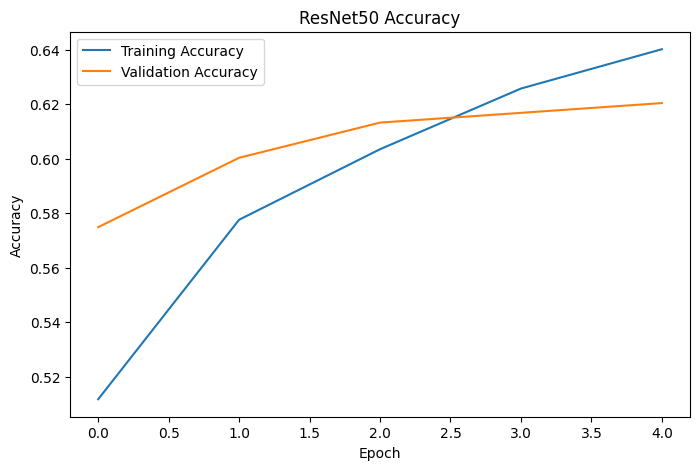

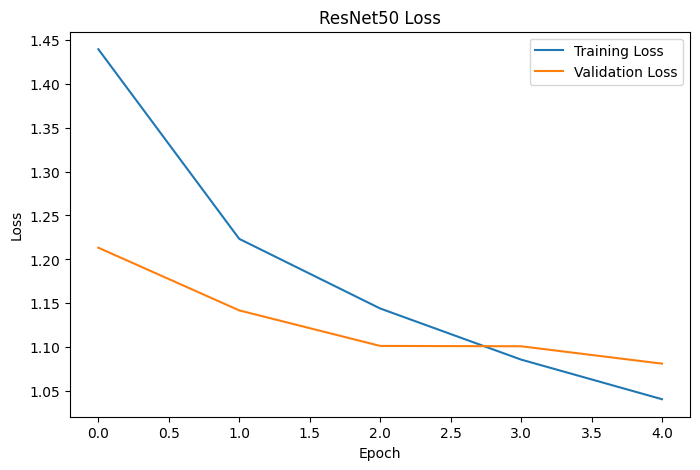

In [18]:
#ResNet50 accuracy

plt.figure(figsize=(8,5))

plt.plot(resnet_history['accuracy'], label='Training Accuracy')
plt.plot(resnet_history['val_accuracy'], label='Validation Accuracy')

plt.title('ResNet50 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

#ResNet50 loss

plt.figure(figsize=(8,5))

plt.plot(resnet_history['loss'], label='Training Loss')
plt.plot(resnet_history['val_loss'], label='Validation Loss')

plt.title('ResNet50 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

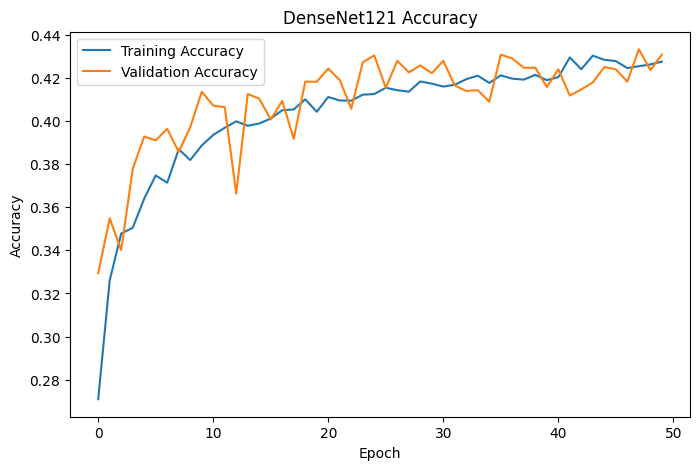

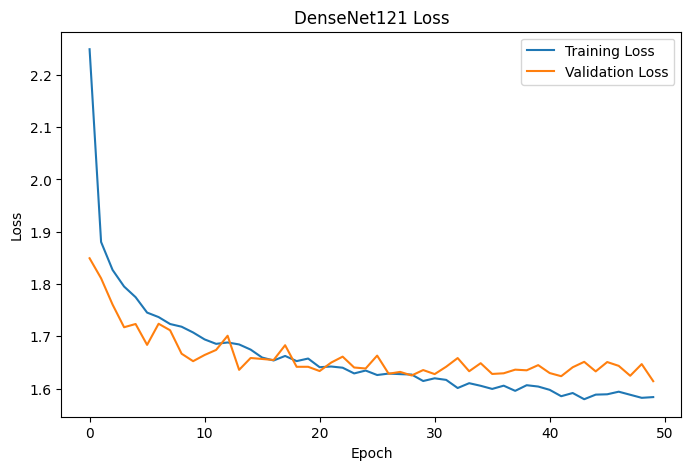

In [19]:
#densenet121 accuracy
plt.figure(figsize=(8,5))

plt.plot(densenet_history['accuracy'], label='Training Accuracy')
plt.plot(densenet_history['val_accuracy'], label='Validation Accuracy')

plt.title('DenseNet121 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

#densenet121 loss
plt.figure(figsize=(8,5))

plt.plot(densenet_history['loss'], label='Training Loss')
plt.plot(densenet_history['val_loss'], label='Validation Loss')

plt.title('DenseNet121 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

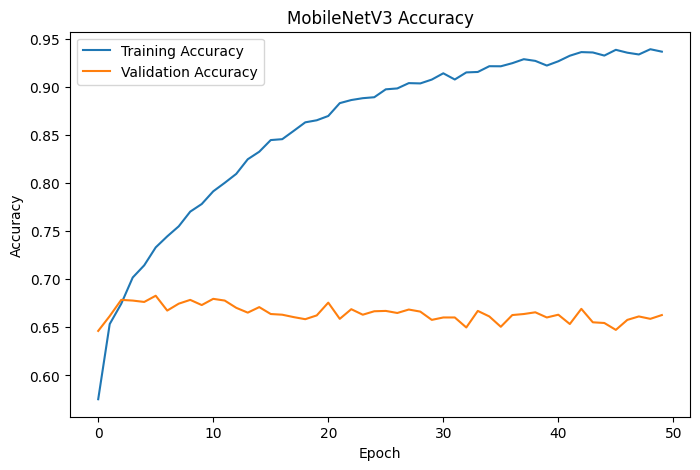

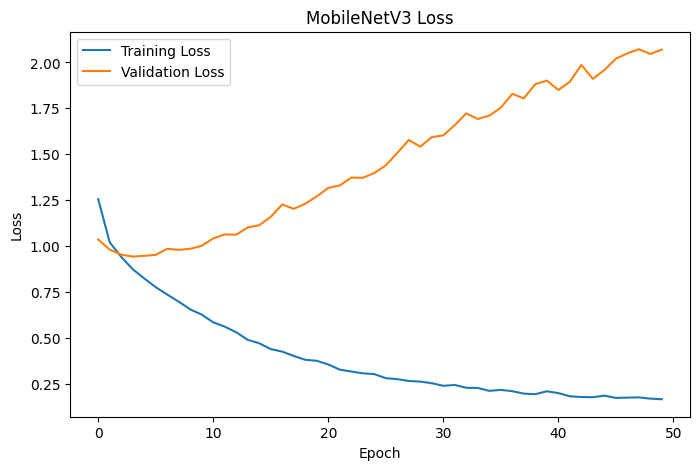

In [20]:
#mobilenet accuracy
plt.figure(figsize=(8,5))

plt.plot(mobilenet_history['accuracy'], label='Training Accuracy')
plt.plot(mobilenet_history['val_accuracy'], label='Validation Accuracy')

plt.title('MobileNetV3 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
#mobilenet loss
plt.figure(figsize=(8,5))

plt.plot(mobilenet_history['loss'], label='Training Loss')
plt.plot(mobilenet_history['val_loss'], label='Validation Loss')

plt.title('MobileNetV3 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [23]:
#final comparison
comparison = pd.DataFrame({
    'Model': ['ResNet50', 'DenseNet121', 'MobileNetV3'],
    'Test Accuracy (%)': [62.32, 42.24, 67.21],
    'mAP': [0.4852, 0.2663, 0.5467],
    'Training Time (minutes)': [48, 35, 31]
})

comparison



,Model,Test Accuracy (%),mAP,Training Time (minutes)
0,ResNet50,62.32,0.4852,48
1,DenseNet121,42.24,0.2663,35
2,MobileNetV3,67.21,0.5467,31


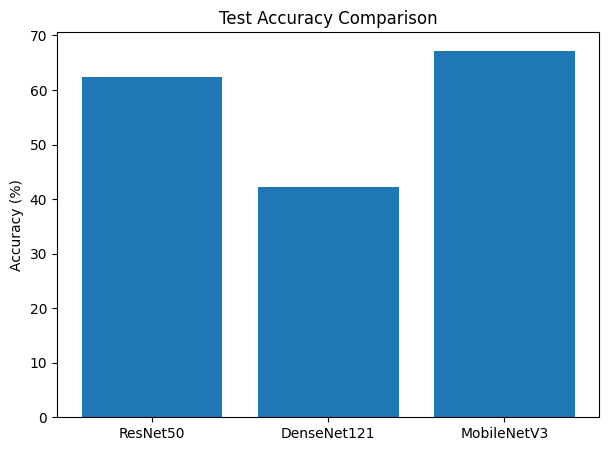

In [24]:
plt.figure(figsize=(7,5))

plt.bar(
    comparison['Model'],
    comparison['Test Accuracy (%)']
)

plt.title('Test Accuracy Comparison')
plt.ylabel('Accuracy (%)')

plt.show()

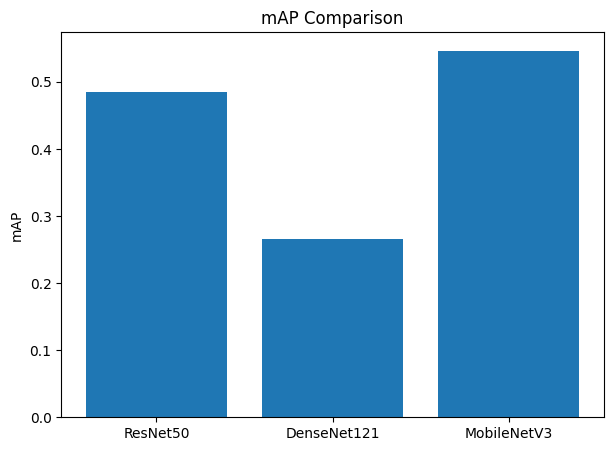

In [25]:
#utk map

plt.figure(figsize=(7,5))

plt.bar(
    comparison['Model'],
    comparison['mAP']
)

plt.title('mAP Comparison')
plt.ylabel('mAP')

plt.show()

In [35]:
y_true = np.load("resnet_y_true.npy")

resnet_pred = np.load("resnet_y_pred.npy")
densenet_pred = np.load("densenet_y_pred.npy")
mobilenet_pred = np.load("mobilenet_y_pred.npy")

In [37]:
class_names = [
    'Abyssinian',
    'American Bobtail',
    'American Shorthair',
    'Bengal',
    'Birman',
    'Bombay',
    'British Shorthair',
    'Maine Coon',
    'Ragdoll',
    'Siamese'
]

print(class_names)

['Abyssinian', 'American Bobtail', 'American Shorthair', 'Bengal', 'Birman', 'Bombay', 'British Shorthair', 'Maine Coon', 'Ragdoll', 'Siamese']


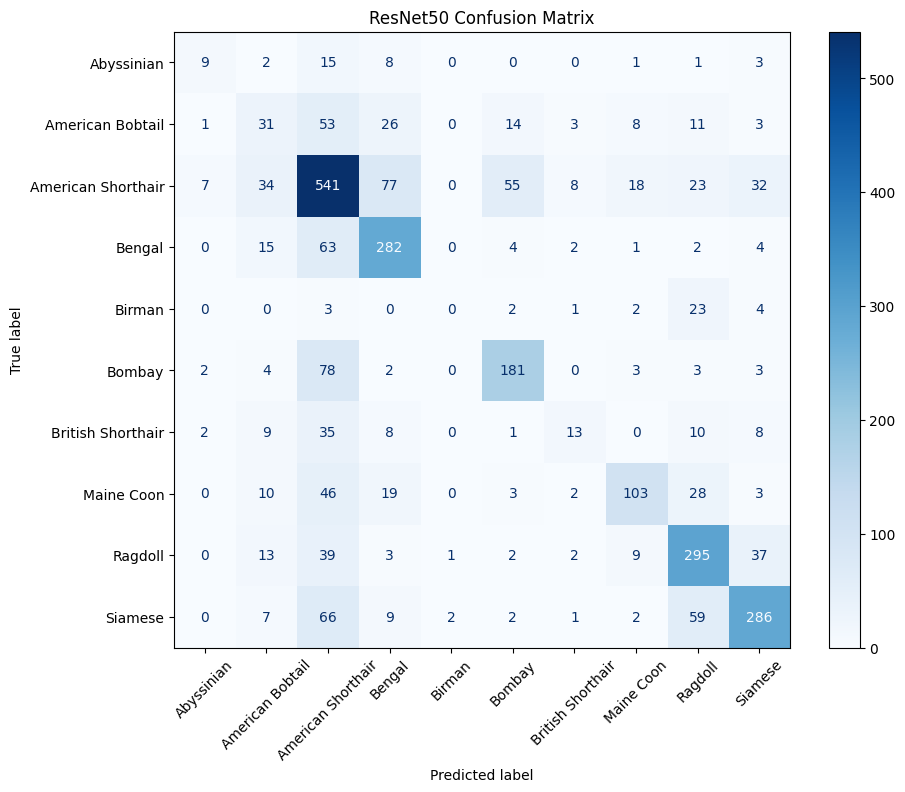

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, resnet_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10,8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)

plt.title("ResNet50 Confusion Matrix")
plt.show()

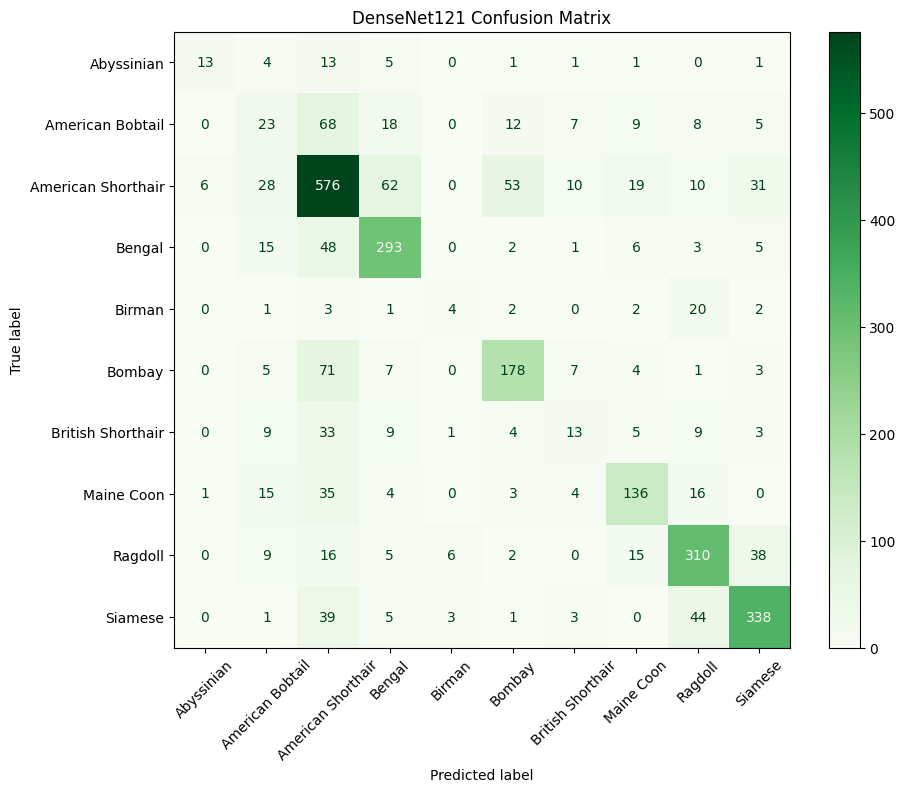

In [39]:
cm = confusion_matrix(y_true, densenet_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10,8))
disp.plot(ax=ax, cmap='Greens', xticks_rotation=45)

plt.title("DenseNet121 Confusion Matrix")
plt.show()

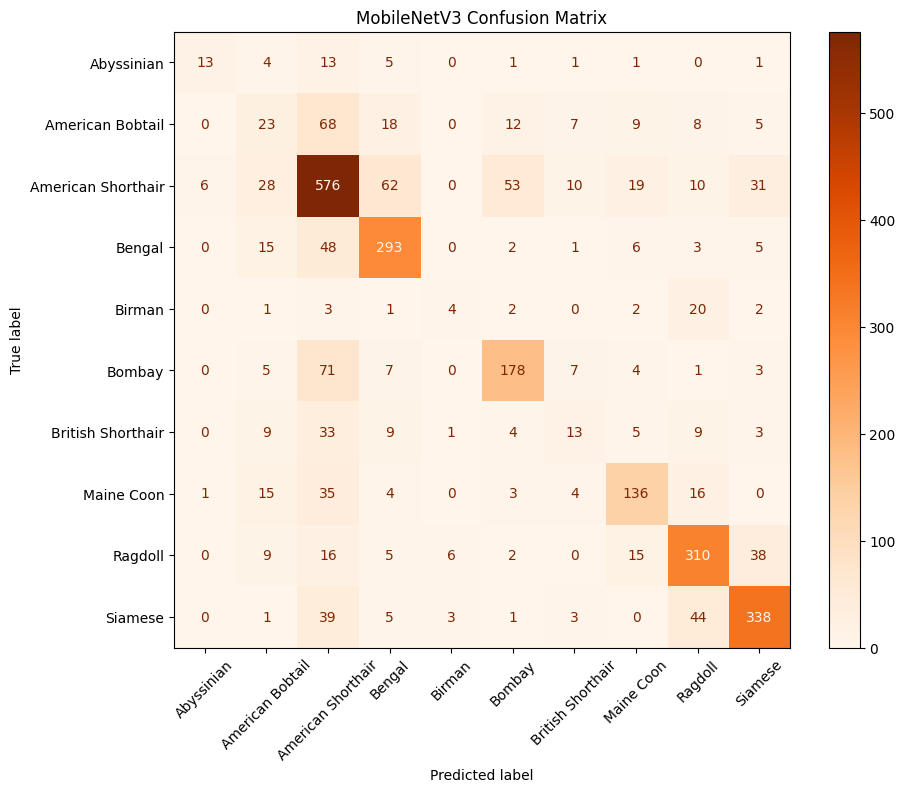

In [40]:
cm = confusion_matrix(y_true, mobilenet_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10,8))
disp.plot(ax=ax, cmap='Oranges', xticks_rotation=45)

plt.title("MobileNetV3 Confusion Matrix")
plt.show()